Bibliotekos

In [1]:
# pip install MissForest
# pip install lightgbm

# !pip install xgboost

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from missforest import MissForest
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from xgboost import XGBRegressor

from datetime import datetime
import pytz

Duomenys

In [3]:
meteo_data = pd.read_csv("Meteo_nauji.csv", sep = ',')
meteo_data.head(5)

,observationTimeUtc,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,precipitation,snowDepth,conditionCode
0,2017-11-01 00:00:00,0.7,-2.5,2.8,6.0,312.0,88.0,1012.1,90.0,0.0,0.0,cloudy
1,2017-11-01 01:00:00,0.4,0.4,0.8,3.5,309.0,88.0,1012.4,91.0,0.0,0.0,cloudy
2,2017-11-01 02:00:00,0.8,0.8,1.0,3.2,247.0,100.0,1012.4,91.0,0.0,0.0,cloudy
3,2017-11-01 03:00:00,0.7,0.7,1.3,3.9,259.0,88.0,1012.3,92.0,0.0,0.0,cloudy
4,2017-11-01 04:00:00,0.5,-2.4,2.5,3.9,238.0,88.0,1011.9,93.0,0.0,0.0,cloudy


In [4]:
meteo_data.shape

(73028, 12)

Duomenų tvarkymas ir paruošimas

In [5]:
clean_meteo_data = meteo_data.drop(columns = ['snowDepth', 'conditionCode'])
clean_meteo_data['observationTimeUtc'] = pd.to_datetime(clean_meteo_data['observationTimeUtc'])
clean_meteo_data.shape

(73028, 10)

Paverčiame į Lietuvos laiką

In [6]:
clean_meteo_data['observationTime'] = (clean_meteo_data['observationTimeUtc'].dt.tz_localize('UTC').dt.tz_convert('Europe/Vilnius'))
clean_meteo_data['observationTime'] = clean_meteo_data['observationTime'].dt.tz_localize(None)
clean_meteo_data = clean_meteo_data.drop(columns = ['observationTimeUtc'])
clean_meteo_data.head(5)

,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,precipitation,observationTime
0,0.7,-2.5,2.8,6.0,312.0,88.0,1012.1,90.0,0.0,2017-11-01 02:00:00
1,0.4,0.4,0.8,3.5,309.0,88.0,1012.4,91.0,0.0,2017-11-01 03:00:00
2,0.8,0.8,1.0,3.2,247.0,100.0,1012.4,91.0,0.0,2017-11-01 04:00:00
3,0.7,0.7,1.3,3.9,259.0,88.0,1012.3,92.0,0.0,2017-11-01 05:00:00
4,0.5,-2.4,2.5,3.9,238.0,88.0,1011.9,93.0,0.0,2017-11-01 06:00:00


Praleistos reikšmės

In [7]:
clean_meteo_data.isnull().sum()

airTemperature            58
feelsLikeTemperature      93
windSpeed                 92
windGust                 138
windDirection             87
cloudCover              1605
seaLevelPressure          68
relativeHumidity          71
precipitation             22
observationTime            0
dtype: int64

In [8]:
station_year = clean_meteo_data["observationTime"].dt.year.unique()
station_year.sort()
nan_year_result = []
for year in station_year:
    nan_year_result.append(clean_meteo_data[clean_meteo_data["observationTime"].dt.year == year].isnull().sum())
nan_year_Vilnius = pd.DataFrame(nan_year_result, index = station_year)
nan_year_Vilnius

,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,precipitation,observationTime
2017,0,0,0,0,0,25,0,0,0,0
2018,0,2,2,8,0,173,1,0,1,0
2019,0,1,1,5,0,130,0,0,3,0
2020,15,20,19,38,18,307,17,18,0,0
2021,0,0,0,1,0,147,0,0,0,0
2022,0,0,0,1,0,272,0,0,0,0
2023,0,0,0,0,0,111,0,0,0,0
2024,32,49,49,53,48,151,32,32,0,0
2025,11,21,21,30,21,263,18,21,18,0
2026,0,0,0,2,0,26,0,0,0,0


In [9]:
clean_meteo_data.groupby(clean_meteo_data['observationTime'].dt.year)['observationTime'].apply(lambda x: x.dt.date.nunique())

observationTime
2017     61
2018    365
2019    365
2020    366
2021    365
2022    365
2023    365
2024    366
2025    365
2026     61
Name: observationTime, dtype: int64

Praleisti stebėjimai pagal kritulius

In [10]:
pd.set_option('display.max_rows', 500)
clean_meteo_data[clean_meteo_data['precipitation'].isnull()]

,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,precipitation,observationTime
3973,18.0,18.0,4.8,NaN,166.0,NaN,1021.9,44.0,NaN,2018-04-15 16:00:00
10688,-1.7,NaN,NaN,NaN,237.0,100.0,1013.6,92.0,NaN,2019-01-20 14:00:00
10997,1.1,-3.6,5.0,9.0,123.0,100.0,1008.3,96.0,NaN,2019-02-02 11:00:00
10998,1.4,-3.2,5.1,9.5,138.0,100.0,1008.0,94.0,NaN,2019-02-02 12:00:00
71076,7.5,NaN,NaN,NaN,NaN,NaN,1014.5,NaN,NaN,2025-12-10 18:00:00
71077,8.0,NaN,NaN,NaN,NaN,NaN,1014.5,NaN,NaN,2025-12-10 19:00:00
71078,8.5,NaN,NaN,NaN,NaN,NaN,1014.4,NaN,NaN,2025-12-10 20:00:00
71079,8.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-12-10 21:00:00
71082,9.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-12-11 00:00:00
71492,0.8,-4.6,6.3,NaN,306.0,100.0,1001.7,91.0,NaN,2025-12-28 02:00:00


Praleistų kritulių reikšmių įrašymas

Missforest metodas:

In [11]:
numeric_data = clean_meteo_data.select_dtypes(include='number')

mf = MissForest()
miss_forest_data = mf.fit_transform(x=numeric_data)
clean_meteo_data['missforest_precipitation'] = miss_forest_data['precipitation']

c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\missforest\missforest.py:333: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
100%|██████████| 5/5 [00:16<00:00,  3.22s/it]
c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\missforest\missforest.py:490: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\missforest\missforest.py:494: UserWarning: In version 4.2.3, estimator fitting process is moved to `fit` method. `MissForest` will now imputes unseen missing values with fitted estimators with `transform` method. To retain the old behaviour, use `fit_transform` to fi

XGBoost motodas:

In [12]:
xgb = IterativeImputer(estimator=XGBRegressor(n_estimators = 100, random_state = 321), max_iter = 10, random_state = 321)
xgb_transformed = xgb.fit_transform(numeric_data)
imputed_df_xgb = pd.DataFrame(xgb_transformed, columns=numeric_data.columns, index=numeric_data.index)
clean_meteo_data['xgb_precipitation'] = imputed_df_xgb['precipitation']

c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Tiesinė interpoliacija:

In [13]:
clean_meteo_data['linear_precipitation'] = clean_meteo_data['precipitation'].interpolate(method='linear')

Įrašymo meotdų palyginimas:

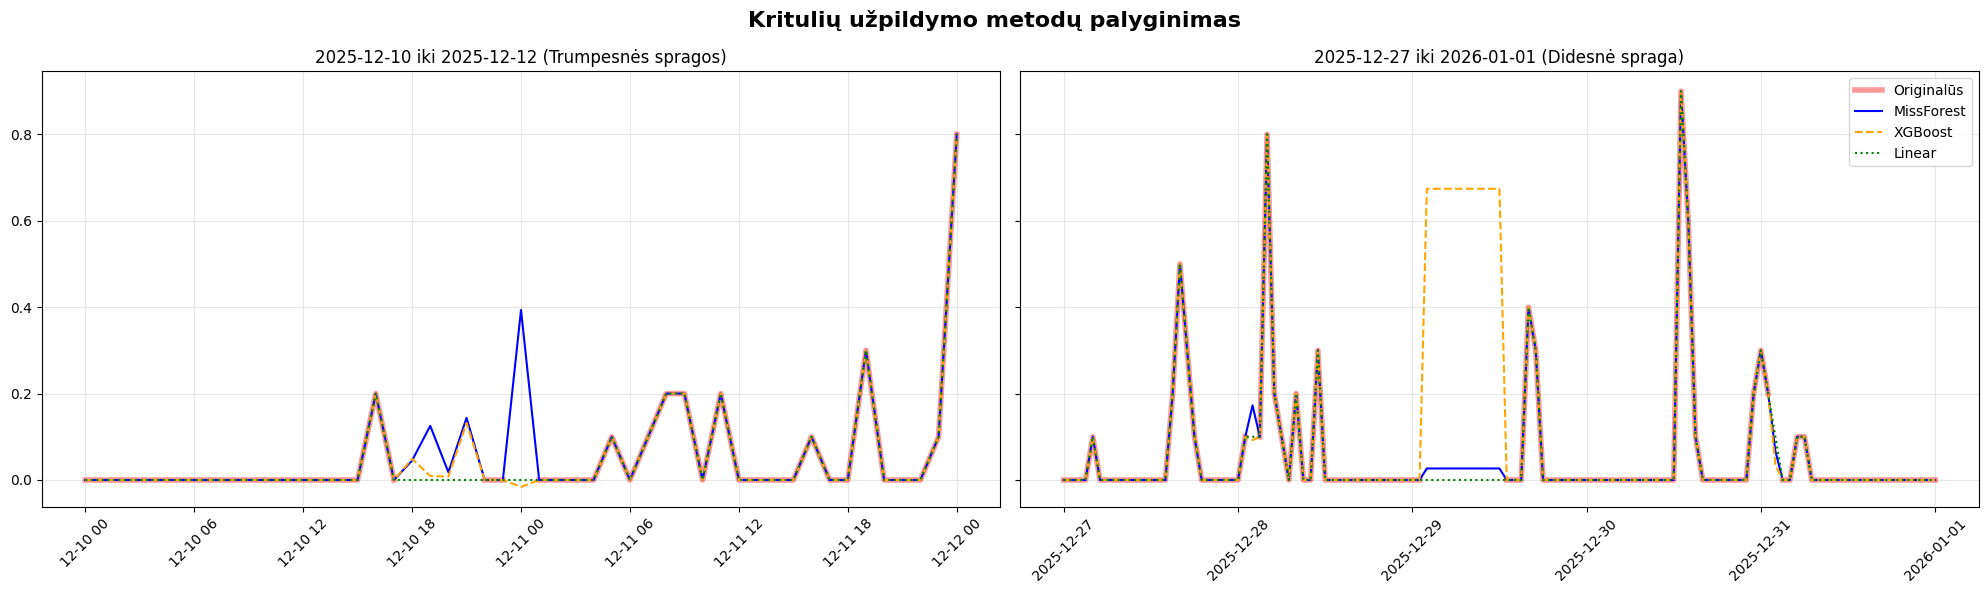

In [14]:
time_mask1 = (clean_meteo_data['observationTime'] >= '2025-12-10') & (clean_meteo_data['observationTime'] <= '2025-12-12')
time_mask2 = (clean_meteo_data['observationTime'] >= '2025-12-27') & (clean_meteo_data['observationTime'] <= '2026-01-01')
filtered_data1 = clean_meteo_data[time_mask1]
filtered_data2 = clean_meteo_data[time_mask2]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

ax1.plot(filtered_data1['observationTime'], filtered_data1['precipitation'], label='Originalūs', color='red', linewidth=4, alpha=0.4)
ax1.plot(filtered_data1['observationTime'], filtered_data1['missforest_precipitation'], label='MissForest', color='blue', linewidth=1.5)
ax1.plot(filtered_data1['observationTime'], filtered_data1['xgb_precipitation'], label='XGBoost', color='orange', linewidth=1.5, linestyle='--')
ax1.plot(filtered_data1['observationTime'], filtered_data1['linear_precipitation'], label='Linear', color='green', linewidth=1.5, linestyle=':')
ax1.set_title('2025-12-10 iki 2025-12-12 (Trumpesnės spragos)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

ax2.plot(filtered_data2['observationTime'], filtered_data2['precipitation'], label='Originalūs', color='red', linewidth=4, alpha=0.4)
ax2.plot(filtered_data2['observationTime'], filtered_data2['missforest_precipitation'], label='MissForest', color='blue', linewidth=1.5)
ax2.plot(filtered_data2['observationTime'], filtered_data2['xgb_precipitation'], label='XGBoost', color='orange', linewidth=1.5, linestyle='--')
ax2.plot(filtered_data2['observationTime'], filtered_data2['linear_precipitation'], label='Linear', color='green', linewidth=1.5, linestyle=':')
ax2.set_title('2025-12-27 iki 2026-01-01 (Didesnė spraga)')
ax2.tick_params(axis='x', rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.suptitle('Kritulių užpildymo metodų palyginimas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Toliau dirbsime su Missforest praleistų kritulių užpildytomis reikšmėmis

In [15]:
clean_meteo_data = clean_meteo_data.drop(columns = ['linear_precipitation', 'precipitation', 'xgb_precipitation'])
clean_meteo_data.head(5)

,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,observationTime,missforest_precipitation
0,0.7,-2.5,2.8,6.0,312.0,88.0,1012.1,90.0,2017-11-01 02:00:00,0.0
1,0.4,0.4,0.8,3.5,309.0,88.0,1012.4,91.0,2017-11-01 03:00:00,0.0
2,0.8,0.8,1.0,3.2,247.0,100.0,1012.4,91.0,2017-11-01 04:00:00,0.0
3,0.7,0.7,1.3,3.9,259.0,88.0,1012.3,92.0,2017-11-01 05:00:00,0.0
4,0.5,-2.4,2.5,3.9,238.0,88.0,1011.9,93.0,2017-11-01 06:00:00,0.0


Duomenų aibės agregavimas

In [16]:
agg_logic = {
    'airTemperature': 'mean',
    'feelsLikeTemperature': 'mean',
    'windSpeed': 'mean',
    'windGust': 'max',
    'windDirection': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
    'cloudCover': 'mean',
    'seaLevelPressure': 'mean',
    'relativeHumidity': 'mean',
    'missforest_precipitation': 'sum'
}

agg_meteo_data = clean_meteo_data.groupby(clean_meteo_data["observationTime"].dt.date).agg(agg_logic)
agg_meteo_data = agg_meteo_data.reset_index()
agg_meteo_data["observationTime"] = pd.to_datetime(agg_meteo_data["observationTime"])
agg_meteo_data

,observationTime,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,missforest_precipitation
0,2017-11-01,4.145455,2.100000,2.800000,10.0,252.0,96.181818,1008.427273,93.954545,7.0
1,2017-11-02,8.333333,6.750000,2.766667,9.3,242.0,94.000000,1000.604167,95.500000,11.7
2,2017-11-03,7.320833,5.770833,2.520833,8.3,294.0,96.000000,1009.004167,94.708333,2.1
3,2017-11-04,6.191667,4.175000,2.775000,7.1,210.0,94.500000,1017.487500,93.166667,0.0
4,2017-11-05,6.229167,3.475000,3.825000,9.5,157.0,72.708333,1015.329167,87.708333,0.0
...,...,...,...,...,...,...,...,...,...,...
3039,2026-02-26,-2.091667,-5.054167,2.904167,8.5,164.0,74.625000,1029.875000,77.875000,0.0
3040,2026-02-27,-0.079167,-4.491667,4.170833,9.4,169.0,73.125000,1023.645833,75.958333,0.0
3041,2026-02-28,3.412500,0.800000,2.758333,5.3,161.0,15.208333,1021.220833,75.375000,0.0
3042,2026-03-01,3.387500,0.379167,3.341667,12.6,160.0,50.625000,1020.195833,81.916667,0.0


In [17]:
agg_meteo_data.isnull().sum()

observationTime              0
airTemperature               0
feelsLikeTemperature         1
windSpeed                    1
windGust                     1
windDirection                1
cloudCover                  10
seaLevelPressure             0
relativeHumidity             0
missforest_precipitation     0
dtype: int64

In [18]:
agg_meteo_data[agg_meteo_data['cloudCover'].isnull()]

,observationTime,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,missforest_precipitation
1127,2020-12-02,-3.100000,-4.700000,1.456250,3.5,140.0,NaN,1028.925000,90.312500,0.0
1128,2020-12-03,-0.775000,-5.087500,4.083333,17.0,148.0,NaN,1021.750000,90.583333,0.0
1129,2020-12-04,0.870833,-4.925000,7.300000,15.4,144.0,NaN,1016.229167,89.833333,0.0
1130,2020-12-05,2.650000,-2.425000,6.745833,14.7,140.0,NaN,1019.679167,93.708333,0.0
1131,2020-12-06,1.008333,-4.654167,7.087500,15.0,141.0,NaN,1025.279167,80.875000,0.0
1522,2022-01-01,2.479167,-1.345833,4.266667,15.4,275.0,NaN,1011.095833,92.541667,0.3
1523,2022-01-02,-2.183333,-6.241667,3.829167,14.5,166.0,NaN,1014.570833,93.750000,9.8
1524,2022-01-03,3.625000,0.404167,3.758333,12.4,301.0,NaN,996.325000,97.541667,6.6
2391,2024-05-19,16.112500,NaN,NaN,NaN,NaN,NaN,1014.837500,73.000000,0.3
2970,2025-12-19,-1.062500,-5.600000,4.045833,9.5,164.0,NaN,1025.870833,99.000000,0.0


Praleistų reikšmių užpildymas naudojant slankujį vidurkį:

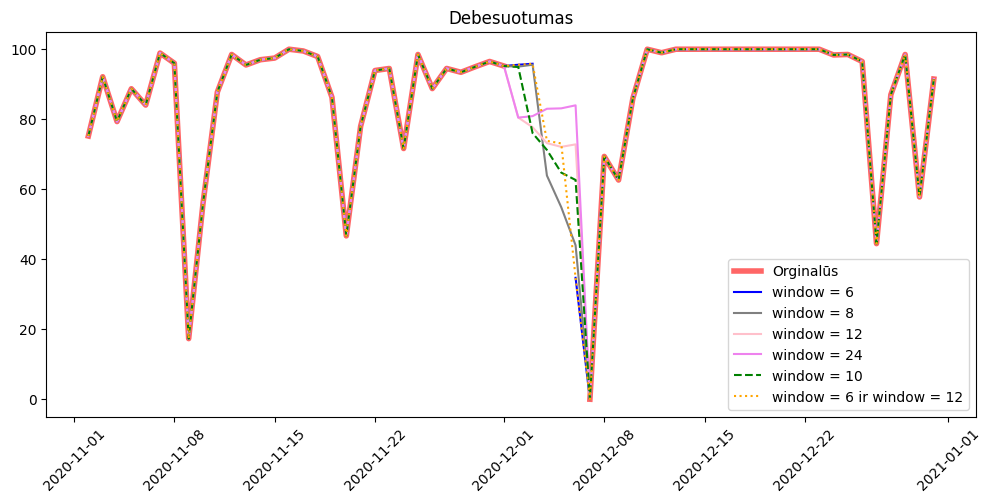

In [19]:
smooth_values1 = agg_meteo_data['cloudCover'].rolling(window=6, min_periods=2, center=True).mean()
agg_meteo_data['cloudCover_fixed_6'] = agg_meteo_data['cloudCover'].fillna(smooth_values1)

smooth_values2 = agg_meteo_data['cloudCover'].rolling(window=8, min_periods=2, center=True).mean()
agg_meteo_data['cloudCover_fixed_8'] = agg_meteo_data['cloudCover'].fillna(smooth_values2)

smooth_values3 = agg_meteo_data['cloudCover'].rolling(window=10, min_periods=2, center=True).mean()
agg_meteo_data['cloudCover_fixed_10'] = agg_meteo_data['cloudCover'].fillna(smooth_values3)

smooth_values4 = agg_meteo_data['cloudCover'].rolling(window=12, min_periods=2, center=True).mean()
agg_meteo_data['cloudCover_fixed_12'] = agg_meteo_data['cloudCover'].fillna(smooth_values4)

smooth_values5 = agg_meteo_data['cloudCover'].rolling(window=18, min_periods=2, center=True).mean()
agg_meteo_data['cloudCover_fixed_24'] = agg_meteo_data['cloudCover'].fillna(smooth_values5)

smooth_values6 = agg_meteo_data['cloudCover_fixed_6'].rolling(window=12, min_periods=2, center=True).mean()
agg_meteo_data['cloudCover_fixed_6_12'] = agg_meteo_data['cloudCover_fixed_6'].fillna(smooth_values6)

time_mask = (agg_meteo_data['observationTime'] > '2020-11-01') & (agg_meteo_data['observationTime'] < '2021-01-01')
filtered_data = agg_meteo_data[time_mask]


fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(filtered_data['observationTime'], filtered_data['cloudCover'], label='Orginalūs', color='red', linewidth=4, alpha=0.6)
ax.plot(filtered_data['observationTime'], filtered_data['cloudCover_fixed_6'], label='window = 6', color='blue', linewidth=1.5)
ax.plot(filtered_data['observationTime'], filtered_data['cloudCover_fixed_8'], label='window = 8', color='grey', linewidth=1.5)
ax.plot(filtered_data['observationTime'], filtered_data['cloudCover_fixed_12'], label='window = 12', color='pink', linewidth=1.5)
ax.plot(filtered_data['observationTime'], filtered_data['cloudCover_fixed_24'], label='window = 24', color='violet', linewidth=1.5)
ax.plot(filtered_data['observationTime'], filtered_data['cloudCover_fixed_10'], label='window = 10', color='green', linewidth=1.5, linestyle='--')
ax.plot(filtered_data['observationTime'], filtered_data['cloudCover_fixed_6_12'], label='window = 6 ir window = 12', color='orange', linewidth=1.5, linestyle=':')
ax.set_title('Debesuotumas')
ax.legend()
plt.xticks(rotation=45)
plt.show()

In [20]:
agg_meteo_data = agg_meteo_data.drop(columns = ['cloudCover', 'cloudCover_fixed_6', 'cloudCover_fixed_12', 'cloudCover_fixed_6_12', 'cloudCover_fixed_8', 'cloudCover_fixed_24'])
agg_meteo_data.head(5)

,observationTime,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,seaLevelPressure,relativeHumidity,missforest_precipitation,cloudCover_fixed_10
0,2017-11-01,4.145455,2.100000,2.800000,10.0,252.0,1008.427273,93.954545,7.0,96.181818
1,2017-11-02,8.333333,6.750000,2.766667,9.3,242.0,1000.604167,95.500000,11.7,94.000000
2,2017-11-03,7.320833,5.770833,2.520833,8.3,294.0,1009.004167,94.708333,2.1,96.000000
3,2017-11-04,6.191667,4.175000,2.775000,7.1,210.0,1017.487500,93.166667,0.0,94.500000
4,2017-11-05,6.229167,3.475000,3.825000,9.5,157.0,1015.329167,87.708333,0.0,72.708333


In [21]:
agg_meteo_data.isnull().sum()

observationTime             0
airTemperature              0
feelsLikeTemperature        1
windSpeed                   1
windGust                    1
windDirection               1
seaLevelPressure            0
relativeHumidity            0
missforest_precipitation    0
cloudCover_fixed_10         0
dtype: int64

In [22]:
cols_to_fix = ['feelsLikeTemperature', 'windSpeed', 'windGust', 'windDirection']

for col in cols_to_fix:
    smooth = agg_meteo_data[col].rolling(window=10, min_periods=2, center=True).mean()
    agg_meteo_data[f'{col}_fixed'] = agg_meteo_data[col].fillna(smooth)

agg_meteo_data = agg_meteo_data.drop(columns = ['feelsLikeTemperature', 'windSpeed', 'windGust', 'windDirection'])
agg_meteo_data = agg_meteo_data.rename(columns={'cloudCover_fixed_10': 'cloudCover_fixed'})
agg_meteo_data.head(5)

,observationTime,airTemperature,seaLevelPressure,relativeHumidity,missforest_precipitation,cloudCover_fixed,feelsLikeTemperature_fixed,windSpeed_fixed,windGust_fixed,windDirection_fixed
0,2017-11-01,4.145455,1008.427273,93.954545,7.0,96.181818,2.100000,2.800000,10.0,252.0
1,2017-11-02,8.333333,1000.604167,95.500000,11.7,94.000000,6.750000,2.766667,9.3,242.0
2,2017-11-03,7.320833,1009.004167,94.708333,2.1,96.000000,5.770833,2.520833,8.3,294.0
3,2017-11-04,6.191667,1017.487500,93.166667,0.0,94.500000,4.175000,2.775000,7.1,210.0
4,2017-11-05,6.229167,1015.329167,87.708333,0.0,72.708333,3.475000,3.825000,9.5,157.0


Duomenų įrašymas

In [23]:
agg_meteo_data.shape

(3044, 10)

In [24]:
agg_meteo_data.to_csv('Vilnius_meteo_data_new_2017_2026.csv', index=False, encoding='utf-8-sig')